In [ ]:
#Libraries

In [1]:
#Data Handling
import pandas as pd
import numpy as np

#Data Visualization 
import matplotlib.pyplot as plt
import seaborn as sns
import os

#Machine Learning (Sklearn)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score,davies_bouldin_score

In [ ]:
#loading the feature engineered csv and directory

In [2]:
df = pd.read_csv("rfm.csv")
rfm_scaled = pd.read_csv("rfm_scaled.csv")

In [4]:
# K-Means Clustering

In [3]:
def kmeans_clustering(data, k):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(data)
    return labels, model

In [ ]:
#Hierarchial Clustering

In [4]:
def hierarchical_clustering(data, k):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(data)
    return labels

In [ ]:
#DBScan 

In [5]:
def dbscan_clustering(data, eps=0.5, min_samples=5):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(data)
    return labels

In [ ]:
#Gaussian Mixture Method 

In [6]:
def gmm_clustering(data, k):
    model = GaussianMixture(n_components=k, random_state=42)
    labels = model.fit_predict(data)
    return labels

In [ ]:
# Elbow methof

Inertia values: [21859.999999999996, 18059.27894915465, 12406.825666460636, 10003.057690803142, 7982.055623830508, 6385.73541168737, 5603.811362632413, 5037.093277061525, 4285.832066635425, 3849.244886574279]


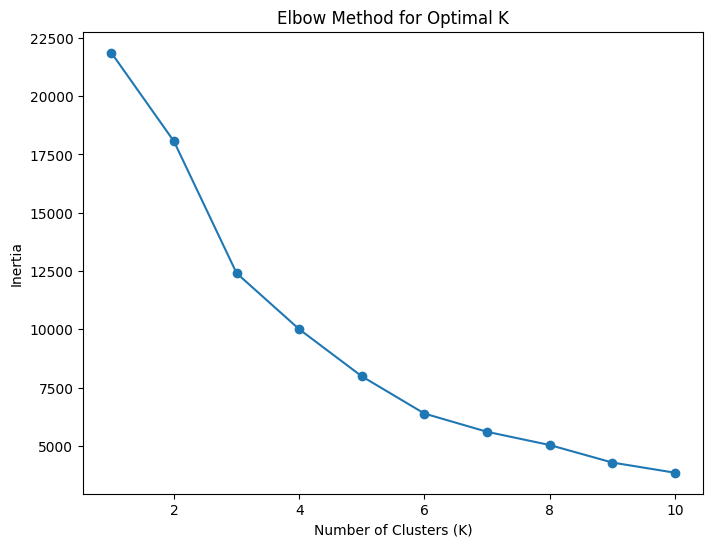

In [7]:

os.makedirs("results/Cluster_Plot", exist_ok=True)

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)   
    inertia.append(model.inertia_)

# Debug check
print("Inertia values:", inertia)

# Plot
plt.figure(figsize=(8,6))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

# Save and Show
plt.savefig("results/Cluster_Plot/elbow_plot.png")
plt.show()



In [ ]:
#Evaluate Score

In [8]:
def evaluate_clusters(data, labels):
    silhouette = silhouette_score(data, labels)
    db_index = davies_bouldin_score(data, labels)
    return silhouette, db_index

In [ ]:
# K=4 was selected based on elbow point stabilization and optimal silhouette score.

In [10]:
labels_kmeans, model = kmeans_clustering(df, k=4)
silhouette, db_index = evaluate_clusters(df, labels_kmeans)
print("Silhouette Score:", silhouette)
print("Davies-Bouldin Index:", db_index)


Silhouette Score: 0.9418951810282664
Davies-Bouldin Index: 0.39789927073500947


In [ ]:
#Cluster Summary

In [11]:
def cluster_summary(rfm_scaled, labels):
    rfm_scaled['Cluster'] = labels
    summary = rfm_scaled.groupby('Cluster').mean()
    return summary
summary = cluster_summary(df, labels_kmeans)
print(summary)

           Recency  Frequency       Monetary  Avg_Order_Value  Purchase_Rate
Cluster                                                                     
0        92.840841   4.570109    1347.627141       304.803639       0.506270
1         3.666667  64.666667  241136.560000      3724.866312      20.925926
2        13.138889  50.722222   35694.129167      1151.396005      15.661590
3         9.500000  96.500000  114451.897500      2231.737204      35.635000


In [ ]:
#Interpretetion

In [12]:
def interpret_clusters(summary):

    print("\n===== CLUSTER INTERPRETATION =====\n")

    interpretations = []

    for cluster in summary.index:

        rec = summary.loc[cluster, 'Recency']
        freq = summary.loc[cluster, 'Frequency']
        mon = summary.loc[cluster, 'Monetary']

        # Default 
        customer_type = ""
        behavior = ""
        spending = ""
        demographics = ""

        # Logic for interpretation
        if mon > summary['Monetary'].mean() and freq > summary['Frequency'].mean():
            customer_type = "High-value premium buyers"
            behavior = "Frequent purchases, highly engaged"
            spending = "High spending per transaction"
            demographics = "Likely loyal, long-term customers"

        elif freq > summary['Frequency'].mean() and mon < summary['Monetary'].mean():
            customer_type = "High-frequency low spenders"
            behavior = "Frequent but small purchases"
            spending = "Low to moderate spending"
            demographics = "Price-sensitive customers"

        elif rec > summary['Recency'].mean():
            customer_type = "At-risk customers"
            behavior = "Inactive for a long time"
            spending = "Declining spending trend"
            demographics = "Likely to churn"

        else:
            customer_type = "Budget occasional shoppers"
            behavior = "Infrequent purchases"
            spending = "Low spending"
            demographics = "Casual or new customers"

        print(f"\n🔹 Cluster {cluster}")
        print(f"Type: {customer_type}")
        print(f"Behavior: {behavior}")
        print(f"Spending: {spending}")
        print(f"Demographics: {demographics}")
        print("-" * 40)

        interpretations.append({
            "Cluster": cluster,
            "Customer_Type": customer_type,
            "Behavior": behavior,
            "Spending": spending,
            "Demographics": demographics
        })

    return interpretations

In [13]:
summary = cluster_summary(df, labels_kmeans)

interpretations = interpret_clusters(summary)


===== CLUSTER INTERPRETATION =====


🔹 Cluster 0
Type: At-risk customers
Behavior: Inactive for a long time
Spending: Declining spending trend
Demographics: Likely to churn
----------------------------------------

🔹 Cluster 1
Type: High-value premium buyers
Behavior: Frequent purchases, highly engaged
Spending: High spending per transaction
Demographics: Likely loyal, long-term customers
----------------------------------------

🔹 Cluster 2
Type: Budget occasional shoppers
Behavior: Infrequent purchases
Spending: Low spending
Demographics: Casual or new customers
----------------------------------------

🔹 Cluster 3
Type: High-value premium buyers
Behavior: Frequent purchases, highly engaged
Spending: High spending per transaction
Demographics: Likely loyal, long-term customers
----------------------------------------


In [17]:
summary.to_csv("rfm_with_clusters.csv", index=False)  